# SpaceXAI compute model

Estimates the compute available to SpaceXAI (xAI + X, including Cursor) at end-2024, end-2025, and mid-2026, in H100-equivalents (H100e).

Nearly all of it is the two Colossus campuses, so the model is anchored on Epoch's [data-center capacity estimates](https://epoch.ai/data/ai-data-centers/directory/colossus-2) rather than chip-fleet accounting:

> `SpaceXAI H100e = Colossus capacity + other compute − cloud sales`

Colossus came online in phases. At each snapshot, capacity is the phases known to be complete plus the in-progress phase times a sampled share of it that was online. Distributions are lognormal unless noted, with bounds as 90% CIs. GB200/GB300 count as ~2.5 H100e (dense 8-bit).

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import squigglepy as sq
from squigglepy.numbers import K

# Shared modules (lab_compute_utils, epoch_data) live at the repo root.
sys.path.insert(0, str(Path('..').resolve()))

N_SAMPLES = 5000
# squigglepy uses its own RNG; np.random.seed has no effect on sq sampling
sq.set_seed(42)

SLATE = "#24343B"       # SpaceXAI accent (near-black slate)
SLATE_DARK = "#0F1419"
RED = "#C25B4E"         # capacity sold to other labs

def fmt(x):
    """Format an H100e count for labels (millions or thousands)."""
    if x >= 1e6:
        return f"{x / 1e6:.2f}M"
    return f"{x / 1e3:.0f}k"

def summary(name, samples):
    """Print 5th / median / 95th and mean for a sample array.

    Values below 10 are treated as fractions and shown as decimals; larger
    values are H100e counts and shown in millions/thousands.
    """
    p = sq.get_percentiles(samples, percentiles=[5, 50, 95])
    f = (lambda x: f"{x:.3f}") if np.median(samples) < 10 else fmt
    print(f"{name}")
    print(f"  90% CI : {f(p[5])} – {f(p[95])}")
    print(f"  median : {f(p[50])}")
    print(f"  mean   : {f(np.mean(samples))}")
    return p

## Parameters

Sampled priors come from `lab_model_params.csv`. Colossus phase sizes are disclosure figures (S-1 chip counts, company announcements) and are literals in the code. `model_spacexai()` in the frontier script implements the same model; the last cell checks the two match.

In [2]:
from lab_compute_utils import load_lab_params, lab_params_table

PARAMS = load_lab_params()["spacexai"]
lab_params_table("spacexai")

,param,dist,low,high,lclip,rclip,units,description,last_updated
0,c1_phase2_complete_2024,norm,0.40,0.95,0.0,1.0,share,Share of Colossus 1 phase 2 (the second 100k H...,9/1/26
1,c2_cluster2_any_live_2025,const,0.33,NaN,NaN,NaN,probability,Probability that ANY of Colossus 2 cluster 2 (...,9/1/26
2,c2_cluster2_share_if_live_2025,norm,0.20,0.66,0.0,1.0,share,Share of Colossus 2 cluster 2 online at Dec 31...,9/1/26
3,colossus_firm_h1_2026,to,1250000.00,1530000.00,NaN,NaN,H100e,Colossus 1 + 2 capacity firm at June 30 2026: ...,9/1/26
4,c2_next_phase_open_h1_2026,norm,0.00,0.15,0.0,1.0,share,Fraction of the next pending Colossus 2 phase ...,7/30/26
5,other_compute_2024,to,20000.00,60000.00,NaN,NaN,H100e,Non-Colossus cloud compute at end-2024: the Or...,8/6/26
6,other_compute_2025,to,30000.00,120000.00,NaN,NaN,H100e,Non-Colossus cloud compute at end-2025: S-1 p....,8/6/26
7,other_compute_h1_2026,to,40000.00,160000.00,NaN,NaN,H100e,Compute outside the two Colossus campuses at m...,7/14/26
8,google_ramp_share,to,0.15,0.50,NaN,1.0,share,Share of the Google deal (~110k GPUs = one of ...,7/14/26
9,anthropic_c2_spillover,uniform,0.00,95000.00,NaN,NaN,H100e,Possible Anthropic capacity on Colossus 2 beyo...,7/14/26


## 1. Colossus milestones

Epoch's timelines give dated H100e estimates per site. The phases used below:

| Phase | H100e | Online |
|---|---|---|
| Colossus 1, phase 1 (100k H100) | 100k | Sep 2024 |
| Colossus 1, phase 2 (second 100k Hoppers) | 100k | credited Feb 2025 |
| Colossus 1 complete (+30k B200) | 276k | Jul 2025 |
| Colossus 2, cluster 1 (~110k GB200) | 278k | Oct 2025 |
| Colossus 2, cluster 2 (110k GB300) | 278k | Apr 2026 |
| Colossus 2, phase 3 (≥220k GB300) | → 1.39M total | Jun 2026 |
| Colossus 2, next phase | +712k | ~Feb 2027 (projected) |

In [3]:
from epoch_data import load_data_center_timelines

TIMELINES = load_data_center_timelines()

SNAPSHOTS = {
    "end-2024": pd.Timestamp("2024-12-31"),
    "end-2025": pd.Timestamp("2025-12-31"),
    "mid-2026": pd.Timestamp("2026-06-30"),
}

In [4]:
# Milestone reference table and chart.
def site_milestones(site):
    """One site's dated milestone H100e estimates, sorted (milestones
    without an H100e estimate are skipped)."""
    rows = (TIMELINES[TIMELINES["Data center"] == site]
            .dropna(subset=["H100 equivalents"]).sort_values("Date"))
    return rows[["Date", "H100 equivalents"]].reset_index(drop=True)

def interp_h100e_at(site, when):
    """Operational H100e at a date, interpolated linearly between milestones
    (flat before the first and after the last)."""
    rows = site_milestones(site)
    days = (rows["Date"] - rows["Date"].iloc[0]).dt.days.to_numpy(dtype=float)
    target = (when - rows["Date"].iloc[0]).days
    return float(np.interp(target, days, rows["H100 equivalents"].to_numpy(dtype=float)))

def level_at(site, when):
    """The last milestone level at or before a date (0 if none) — how a
    phase-built site reads at a snapshot."""
    rows = site_milestones(site)
    before = rows[rows["Date"] <= when]
    return float(before["H100 equivalents"].iloc[-1]) if len(before) else 0.0

print(f"{'snapshot':>10}  {'C1 (interpolated)':>18}  {'C2 (level)':>11}  {'sum':>7}")
for name, when in SNAPSHOTS.items():
    c1, c2 = interp_h100e_at("Colossus 1", when), level_at("Colossus 2", when)
    print(f"{name:>10}  {fmt(c1):>18}  {fmt(c2):>11}  {fmt(c1 + c2):>7}")

  snapshot   C1 (interpolated)   C2 (level)      sum
  end-2024                171k           0k     171k
  end-2025                276k         278k     554k
  mid-2026                276k        1.11M    1.39M


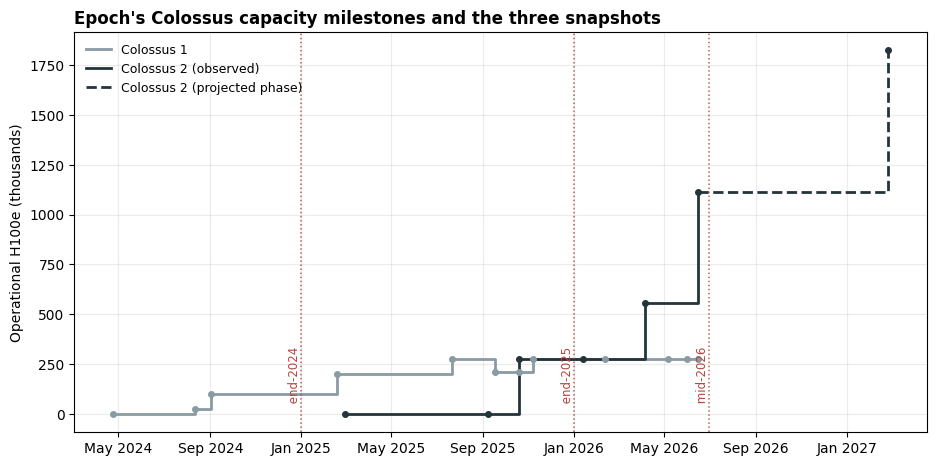

In [5]:
# Timeline chart: milestone step curves per site, the projected C2 phase
# dashed, snapshot dates as vertical lines.
c1_rows = site_milestones("Colossus 1")
c2_rows = site_milestones("Colossus 2")

fig, ax = plt.subplots(figsize=(11, 5.2))
ax.step(c1_rows["Date"], c1_rows["H100 equivalents"] / 1e3, where="post",
        color="#8A9BA3", lw=2, label="Colossus 1")
c2_observed = c2_rows[c2_rows["Date"] <= pd.Timestamp("2026-06-15")]
c2_projected = c2_rows[c2_rows["Date"] >= pd.Timestamp("2026-06-15")]
ax.step(c2_observed["Date"], c2_observed["H100 equivalents"] / 1e3,
        where="post", color=SLATE, lw=2, label="Colossus 2 (observed)")
ax.step(c2_projected["Date"], c2_projected["H100 equivalents"] / 1e3,
        where="post", color=SLATE, lw=2, ls="--",
        label="Colossus 2 (projected phase)")
ax.plot(c1_rows["Date"], c1_rows["H100 equivalents"] / 1e3, "o",
        color="#8A9BA3", ms=4)
ax.plot(c2_rows["Date"], c2_rows["H100 equivalents"] / 1e3, "o",
        color=SLATE, ms=4)

for name, when in SNAPSHOTS.items():
    ax.axvline(when, color="#B4443C", lw=1.1, ls=":", alpha=0.85)
    ax.text(when, ax.get_ylim()[1] * 0.02, f" {name}", rotation=90,
            va="bottom", ha="right", fontsize=8.5, color="#B4443C")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.set_ylabel("Operational H100e (thousands)")
ax.set_title("Epoch's Colossus capacity milestones and the three snapshots",
             loc="left", weight="bold")
ax.legend(loc="upper left", frameon=False, fontsize=9)
ax.grid(alpha=0.25)
plt.show()

## 2. End-2024

Phase 1 (100k) is fixed. Phase 2 (the second 100k) was in progress at Dec 31: its completion share is sampled, normal with 90% CI 0.40–0.95 (linear interpolation between Epoch's milestones gives 0.71).

Other compute is non-Colossus cloud capacity, mainly the Oracle cluster used for Grok-2.

In [6]:
C1_PHASE1 = 100 * K   # online by September (company announcement)
C1_PHASE2 = 100 * K   # the second 100k Hoppers, credited by Epoch in February

c1_phase2_complete = PARAMS["c1_phase2_complete_2024"] @ N_SAMPLES
colossus_2024 = C1_PHASE1 + C1_PHASE2 * c1_phase2_complete
other_2024 = PARAMS["other_compute_2024"] @ N_SAMPLES
spacexai_2024 = colossus_2024 + other_2024

summary("C1 phase 2 completion share (Dec 31)", c1_phase2_complete)
summary("Colossus operational (end-2024)", colossus_2024)
summary("Other sites + cloud purchases (end-2024)", other_2024)
summary("SpaceXAI compute, end-2024", spacexai_2024);

C1 phase 2 completion share (Dec 31)
  90% CI : 0.393 – 0.945
  median : 0.674
  mean   : 0.670
Colossus operational (end-2024)
  90% CI : 139k – 195k
  median : 167k
  mean   : 167k
Other sites + cloud purchases (end-2024)
  90% CI : 20k – 60k
  median : 34k
  mean   : 37k
SpaceXAI compute, end-2024
  90% CI : 171k – 237k
  median : 203k
  mean   : 204k


## 3. End-2025

Colossus 1 (276k) and Colossus 2 cluster 1 (278k) are complete: 554k. Cluster 2 (278k) was under construction, and its share online is sampled in two parts:

- probability that any of it was live: 0.33;
- if live, share ~ normal(0.20, 0.66), median 0.43 (the linear ramp from cluster 1's Oct 19 start to Epoch's Apr 6 completion date).

So the share is 0 in the median case with a right tail. Other compute is bounded by the S-1's infrastructure-and-cloud expense lines.

In [7]:
C1 = 276 * K           # Colossus 1: 150k H100 + 50k H200 + 30k B200
C2_CLUSTER1 = 278 * K  # Colossus 2 cluster 1: 110k GB200, online Oct 19 2025
C2_CLUSTER2 = 278 * K  # Colossus 2 cluster 2: 110k GB300, Epoch-dated Apr 6 2026

In [8]:
# Share of cluster 2 online: zero unless any was live, else the share-if-live draw.
p_any_live = PARAMS["c2_cluster2_any_live_2025"]            # sheet const, a plain float
share_if_live = PARAMS["c2_cluster2_share_if_live_2025"]    # clipped normal
c2_cluster2_complete = sq.mixture([sq.const(0), share_if_live],
                                  [1 - p_any_live, p_any_live]) @ N_SAMPLES
colossus_2025 = C1 + C2_CLUSTER1 + C2_CLUSTER2 * c2_cluster2_complete
other_2025 = PARAMS["other_compute_2025"] @ N_SAMPLES
spacexai_2025 = colossus_2025 + other_2025

p = summary("C2 cluster 2 share online (Dec 31)", c2_cluster2_complete)
print(f"  P(any live) = {np.mean(c2_cluster2_complete > 0):.0%}\n")
summary("Colossus operational (end-2025)", colossus_2025)
summary("Other sites + cloud purchases (end-2025)", other_2025)
summary("SpaceXAI compute, end-2025", spacexai_2025);

C2 cluster 2 share online (Dec 31)
  90% CI : 0.000 – 0.577
  median : 0.000
  mean   : 0.146
  P(any live) = 34%

Colossus operational (end-2025)
  90% CI : 554k – 714k
  median : 554k
  mean   : 595k
Other sites + cloud purchases (end-2025)
  90% CI : 30k – 122k
  median : 61k
  mean   : 66k
SpaceXAI compute, end-2025
  90% CI : 587k – 787k
  median : 635k
  mean   : 661k


## 4. Mid-2026: the fleet

Everything through Colossus 2's 400+ MW phase 3 is treated as firm: `to(1.25M, 1.53M)`, Epoch's 1.39M ±10%. The next phase (+712k, projected ~Feb 2027) had been under way for 15 days, so the share open is a clipped normal with median ~7%.

In [9]:
colossus_firm_h1_2026 = PARAMS["colossus_firm_h1_2026"] @ N_SAMPLES
C2_PENDING_FEB2027 = 712 * K
phase_open = PARAMS["c2_next_phase_open_h1_2026"] @ N_SAMPLES

colossus_h1_2026 = colossus_firm_h1_2026 + C2_PENDING_FEB2027 * phase_open
other_h1_2026 = PARAMS["other_compute_h1_2026"] @ N_SAMPLES
fleet_h1_2026 = colossus_h1_2026 + other_h1_2026

p = summary("Share of the ~Feb 2027 C2 phase open", phase_open)
print(f"  P(nothing open) = {np.mean(phase_open == 0.0):.0%}\n")
summary("Colossus operational (mid-2026)", colossus_h1_2026)
summary("Total SpaceX fleet (mid-2026)", fleet_h1_2026);

Share of the ~Feb 2027 C2 phase open
  90% CI : 0.001 – 0.150
  median : 0.075
  mean   : 0.076
  P(nothing open) = 5%

Colossus operational (mid-2026)
  90% CI : 1.30M – 1.59M
  median : 1.44M
  mean   : 1.44M
Total SpaceX fleet (mid-2026)
  90% CI : 1.37M – 1.70M
  median : 1.52M
  mean   : 1.53M


## 5. Mid-2026: cloud sales

Capacity SpaceX rents to other labs from May–July 2026 is subtracted:

- Anthropic: all of Colossus 1 (276k, the same fixed level as in the fleet) plus uniform 0–95k of Colossus 2 spillover;
- Google: one 278k Colossus 2 cluster, ramping through September; June 30 share `to(0.15, 0.5)`;
- Reflection AI: carve-out billing from July 1; uniform 0–45k.

Cursor's compute agreement is an internal allocation and stays in.

In [10]:
anthropic_spillover = PARAMS["anthropic_c2_spillover"] @ N_SAMPLES
anthropic_sold = C1 + anthropic_spillover

google_ramp = PARAMS["google_ramp_share"] @ N_SAMPLES
google_sold = C2_CLUSTER1 * google_ramp

reflection_sold = PARAMS["reflection_sold_h100e"] @ N_SAMPLES

spacexai_h1_2026 = fleet_h1_2026 - anthropic_sold - google_sold - reflection_sold

summary("Sold to Anthropic (all of C1 + spillover)", anthropic_sold)
summary("Sold to Google (one C2 cluster, ramping)", google_sold)
summary("Sold to Reflection AI", reflection_sold)
summary("SpaceXAI compute, mid-2026", spacexai_h1_2026);

Sold to Anthropic (all of C1 + spillover)
  90% CI : 281k – 366k
  median : 324k
  mean   : 323k
Sold to Google (one C2 cluster, ramping)
  90% CI : 42k – 139k
  median : 75k
  mean   : 81k
Sold to Reflection AI
  90% CI : 2k – 43k
  median : 22k
  mean   : 22k
SpaceXAI compute, mid-2026
  90% CI : 924k – 1.29M
  median : 1.10M
  mean   : 1.10M


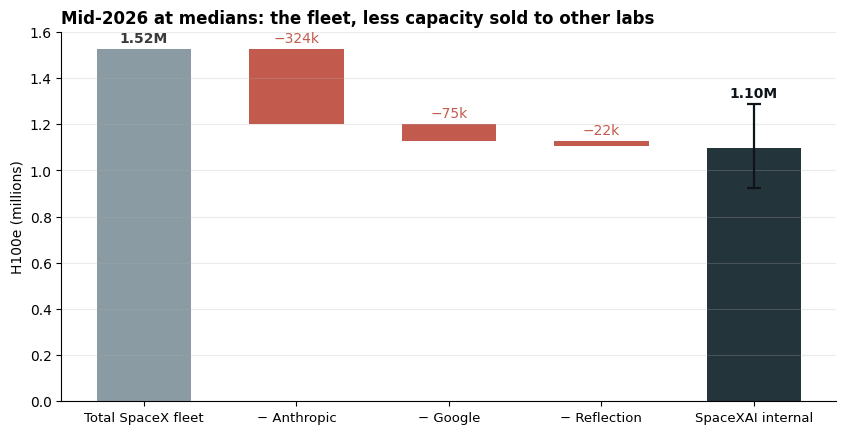

In [11]:
# Waterfall at medians; the last bar carries the full 90% CI.
wf_fleet = np.median(fleet_h1_2026)
wf_sales = [("Anthropic", np.median(anthropic_sold)),
            ("Google", np.median(google_sold)),
            ("Reflection", np.median(reflection_sold))]
wf_lo, wf_med, wf_hi = np.percentile(spacexai_h1_2026, [5, 50, 95])

fig, ax = plt.subplots(figsize=(10, 4.8))
labels = ["Total SpaceX fleet"] + [f"− {n}" for n, _ in wf_sales] + ["SpaceXAI internal"]
running = wf_fleet
ax.bar(0, wf_fleet / 1e6, width=0.62, color="#8A9BA3")
ax.text(0, wf_fleet / 1e6 + 0.03, fmt(wf_fleet), ha="center", fontsize=10,
        fontweight="bold", color="#3a3a3a")
for i, (name, sold) in enumerate(wf_sales, start=1):
    ax.bar(i, sold / 1e6, bottom=(running - sold) / 1e6, width=0.62, color=RED)
    ax.text(i, running / 1e6 + 0.03, f"−{fmt(sold)}", ha="center", fontsize=10,
            color=RED)
    running -= sold
ax.bar(len(labels) - 1, wf_med / 1e6, width=0.62, color=SLATE)
ax.errorbar(len(labels) - 1, wf_med / 1e6,
            yerr=[[(wf_med - wf_lo) / 1e6], [(wf_hi - wf_med) / 1e6]],
            fmt="none", ecolor=SLATE_DARK, elinewidth=1.6, capsize=5,
            capthick=1.6, zorder=3)
ax.text(len(labels) - 1, wf_hi / 1e6 + 0.03, fmt(wf_med), ha="center",
        fontsize=10, fontweight="bold", color=SLATE_DARK)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=9.5)
ax.set_ylabel("H100e (millions)")
ax.set_title("Mid-2026 at medians: the fleet, less capacity sold to other labs",
             loc="left", weight="bold")
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.grid(alpha=0.25, axis="y")
plt.show()

## 6. Results

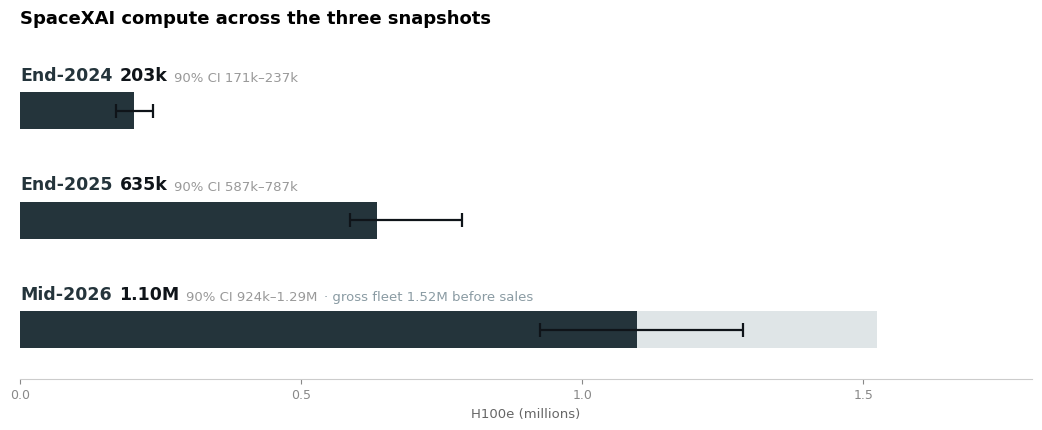

In [12]:
def label_spans(ax, x, y, spans, pad_px=7):
    """Draw text spans left-to-right starting at data-x, each with its own style."""
    for txt, kw in spans:
        t = ax.text(x, y, txt, ha="left", va="bottom", **kw)
        ax.figure.canvas.draw()
        x = ax.transData.inverted().transform(
            (t.get_window_extent().x1 + pad_px, 0))[0]

results = [
    ("End-2024", spacexai_2024, None),
    ("End-2025", spacexai_2025, None),
    ("Mid-2026", spacexai_h1_2026, fleet_h1_2026),
]

fig, ax = plt.subplots(figsize=(11, 4.6))
fig.subplots_adjust(left=0.05, right=0.97, top=0.86, bottom=0.13)
ax.set_xlim(0, 1.8)
ax.set_ylim(-0.45, len(results) - 1 + 0.62)

bar_h = 0.34
for i, (name, samples, gross) in enumerate(results):
    y = len(results) - 1 - i
    lo, med, hi = np.percentile(samples, [5, 50, 95])
    if gross is not None:
        # ghost bar: the gross fleet before netting out cloud sales
        glo, gmed, ghi = np.percentile(gross, [5, 50, 95])
        ax.barh(y, gmed / 1e6, height=bar_h, color="#DFE5E7", zorder=1)
    ax.barh(y, med / 1e6, height=bar_h, color=SLATE, zorder=2)
    ax.errorbar(med / 1e6, y, xerr=[[(med - lo) / 1e6], [(hi - med) / 1e6]],
                fmt="none", ecolor=SLATE_DARK, elinewidth=1.6, capsize=5,
                capthick=1.6, zorder=3)
    spans = [
        (name, dict(fontsize=12.5, fontweight="bold", color=SLATE)),
        (fmt(med), dict(fontsize=12.5, fontweight="bold", color=SLATE_DARK)),
        (f"90% CI {fmt(lo)}–{fmt(hi)}", dict(fontsize=9.5, color="#999999")),
    ]
    if gross is not None:
        spans.append((f"· gross fleet {fmt(gmed)} before sales",
                      dict(fontsize=9.5, color="#8A9BA3")))
    label_spans(ax, 0, y + 0.24, spans)

for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
ax.spines["bottom"].set_color("#cccccc")
ax.set_yticks([])
ax.set_xticks([0, 0.5, 1, 1.5])
ax.tick_params(axis="x", colors="#888888", labelsize=9)
ax.set_xlabel("H100e (millions)", color="#666666", fontsize=9.5)
ax.set_title("SpaceXAI compute across the three snapshots",
             loc="left", fontsize=13, weight="bold", pad=14)
plt.show()

## Sensitivity (mid-2026)

Each input pinned at its 5th and then 95th percentile with everything else sampled; the bar spans the two resulting medians.

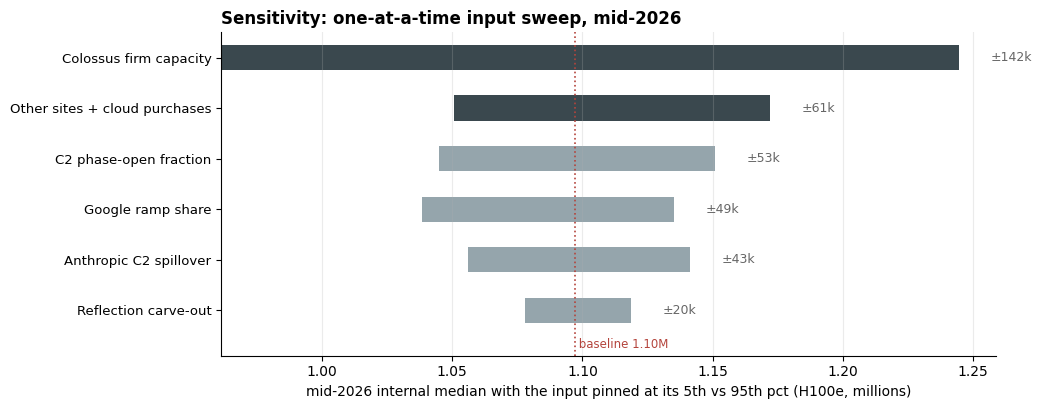

In [13]:
def internal_with(firm=None, phase=None, other=None, spill=None, ramp=None,
                  refl=None):
    """Recompute the mid-2026 internal estimate with some inputs pinned to
    scalars (None keeps the sampled array)."""
    firm = colossus_firm_h1_2026 if firm is None else firm
    phase = phase_open if phase is None else phase
    other = other_h1_2026 if other is None else other
    spill = anthropic_spillover if spill is None else spill
    ramp = google_ramp if ramp is None else ramp
    refl = reflection_sold if refl is None else refl
    fleet = firm + C2_PENDING_FEB2027 * phase + other
    sold = (C1 + spill) + C2_CLUSTER1 * ramp + refl
    return fleet - sold

tornado_inputs = [
    ("Colossus firm capacity", "firm", colossus_firm_h1_2026),
    ("C2 phase-open fraction", "phase", phase_open),
    ("Other sites + cloud purchases", "other", other_h1_2026),
    ("Anthropic C2 spillover", "spill", anthropic_spillover),
    ("Google ramp share", "ramp", google_ramp),
    ("Reflection carve-out", "refl", reflection_sold),
]

baseline_med = np.median(spacexai_h1_2026)
tornado = []
for label, kw, samples in tornado_inputs:
    lo_med = np.median(internal_with(**{kw: np.percentile(samples, 5)}))
    hi_med = np.median(internal_with(**{kw: np.percentile(samples, 95)}))
    tornado.append((label, lo_med, hi_med))
tornado.sort(key=lambda r: abs(r[2] - r[1]), reverse=True)

fig, ax = plt.subplots(figsize=(10, 4.2))
for i, (label, lo_med, hi_med) in enumerate(tornado):
    y = len(tornado) - 1 - i
    left, width = min(lo_med, hi_med), abs(hi_med - lo_med)
    ax.barh(y, width / 1e6, left=left / 1e6, height=0.5,
            color=SLATE if i < 2 else "#8A9BA3", alpha=0.9)
    ax.text(max(lo_med, hi_med) / 1e6 + 0.012, y, f"±{fmt(width / 2)}",
            va="center", fontsize=9, color="#666666")
ax.axvline(baseline_med / 1e6, color="#B4443C", lw=1.2, ls=":")
ax.set_ylim(-0.9, len(tornado) - 0.5)
ax.text(baseline_med / 1e6, -0.8, f" baseline {fmt(baseline_med)}",
        fontsize=8.5, color="#B4443C", va="bottom")
ax.set_yticks(range(len(tornado)))
ax.set_yticklabels([r[0] for r in reversed(tornado)], fontsize=9.5)
ax.set_xlabel("mid-2026 internal median with the input pinned at its 5th vs 95th pct (H100e, millions)")
ax.set_title("Sensitivity: one-at-a-time input sweep, mid-2026",
             loc="left", weight="bold")
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.grid(alpha=0.25, axis="x")
plt.show()

## Cross-check against the frontier script

In [14]:
import frontier_lab_compute_model as frontier

frontier_res = frontier.model_spacexai()
assert np.allclose(frontier_res["2024"], spacexai_2024)
assert np.allclose(frontier_res["2025"], spacexai_2025)
assert np.allclose(frontier_res["h1_2026"], spacexai_h1_2026)
print("matches frontier_lab_compute_model.model_spacexai exactly")

matches frontier_lab_compute_model.model_spacexai exactly


## Bottom line

- End-2024: ~203k H100e (90% CI ~171–237k).
- End-2025: ~635k H100e (90% CI ~587–787k).
- Mid-2026: ~1.10M H100e internal (90% CI ~929k–1.29M), from a ~1.53M gross fleet before cloud sales.